# Testando e comparando os modelos de Detecção de Emoções

## Etapa 1 - Importando as bibliotecas

In [1]:
!pip install -q tf_keras

In [11]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!pip install opencv-python-headless==4.12.0.88

Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 10.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
import zipfile
%tensorflow_version 2.x
import tensorflow
tensorflow.__version__

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


'2.20.0'

## Etapa 2 - Conectando com o Drive e acessando os arquivos

In [4]:
from google.colab import drive  # Importa a ferramenta do Google Colab para acessar o Google Drive
drive.mount('/content/gdrive')  # Conecta o Google Drive ao ambiente do Google Colab
path = "/content/gdrive/MyDrive/Colab Notebooks/Card 23/aula/Material.zip"  # Define o caminho onde está localizado o arquivo ZIP no Google Drive
zip_object = zipfile.ZipFile(file=path, mode="r")  # Abre o arquivo ZIP em modo de leitura
zip_object.extractall("./")  # Extrai todos os arquivos do ZIP para o diretório atual
zip_object.close  # Fecha o arquivo ZIP

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


<bound method ZipFile.close of <zipfile.ZipFile filename='/content/gdrive/MyDrive/Colab Notebooks/Card 23/aula/Material.zip' mode='r'>>

# Faz uma comparação

In [5]:
from tf_keras.models import load_model
import operator

# Nome dos modelos que serão comparados
arquivos_modelos = ["modelo_01_expressoes.h5", "modelo_02_expressoes.h5", "modelo_03_expressoes.h5", "modelo_04_expressoes.h5", "modelo_05_expressoes.h5"]

modelos = {}

x_test = np.load('Material/mod_xtest.npy')
y_test = np.load('Material/mod_ytest.npy')

for modelo in arquivos_modelos:
  model = load_model('Material/' + modelo)

  # Calcula a acurácia do modelo obtida ao testar na base de teste
  scores = model.evaluate(np.array(x_test), np.array(y_test), batch_size=64)
  print("---"+ str(modelo) +"---")
  print("Perda/Loss: " + str(scores[0]))
  print("Acurácia: " + str(scores[1]))
  modelos[modelo] = str(scores[1])
  print("\n")

57/57 [==============================] - 62s 1s/step - loss: 1.0704 - accuracy: 0.6392
---modelo_01_expressoes.h5---
Perda/Loss: 1.070416808128357
Acurácia: 0.6391752362251282


57/57 [==============================] - 23s 390ms/step - loss: 1.0119 - accuracy: 0.6411
---modelo_02_expressoes.h5---
Perda/Loss: 1.0118968486785889
Acurácia: 0.6411256790161133


57/57 [==============================] - 59s 1s/step - loss: 1.0732 - accuracy: 0.6308
---modelo_03_expressoes.h5---
Perda/Loss: 1.0731697082519531
Acurácia: 0.6308164000511169


57/57 [==============================] - 90s 2s/step - loss: 1.1691 - accuracy: 0.6160
---modelo_04_expressoes.h5---
Perda/Loss: 1.169052004814148
Acurácia: 0.61604905128479


57/57 [==============================] - 68s 1s/step - loss: 1.8206 - accuracy: 0.2455
---modelo_05_expressoes.h5---
Perda/Loss: 1.820610761642456
Acurácia: 0.2454722821712494




In [6]:
# Ordena em ordem decrescente os modelos com base no valor da acurácia
order_modelos = sorted(modelos.items(), key=operator.itemgetter(1), reverse=True)
print(order_modelos)

[('modelo_02_expressoes.h5', '0.6411256790161133'), ('modelo_01_expressoes.h5', '0.6391752362251282'), ('modelo_03_expressoes.h5', '0.6308164000511169'), ('modelo_04_expressoes.h5', '0.61604905128479'), ('modelo_05_expressoes.h5', '0.2454722821712494')]


In [7]:
order_modelos[0]

('modelo_02_expressoes.h5', '0.6411256790161133')

## Teste com o modelo carregado

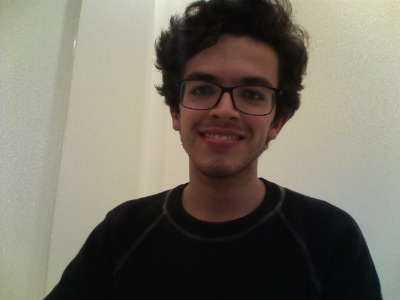

In [8]:
imagem = cv2.imread("Material/testes/teste_gabriel.png")  # Carrega a imagem a partir do caminho informado
cv2_imshow(imagem)  # Exibe a imagem

In [9]:
cascade_faces = 'Material/haarcascade_frontalface_default.xml'  # Define o caminho do classificador Haar Cascade para detectar rostos
caminho_modelo = 'Material/' + str(order_modelos[0][0])  # Monta o caminho do modelo de emoções selecionado
face_detection = cv2.CascadeClassifier(cascade_faces)  # Carrega o classificador responsável pela detecção de faces
classificador_emocoes = load_model(caminho_modelo, compile=False)  # Carrega o modelo treinado para classificar as emoções
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]  # Define as classes de emoções que o modelo pode identificar

1/1 [==============================] - 0s 329ms/step
[1.2285657e-03 8.9724359e-05 7.5628160e-04 9.4787621e-01 2.9239720e-03
 5.5896194e-04 4.6566229e-02]


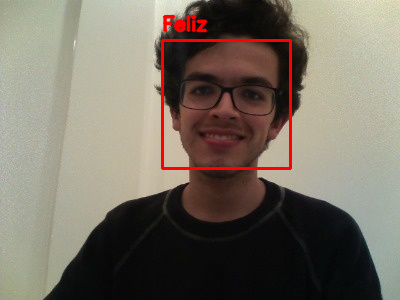

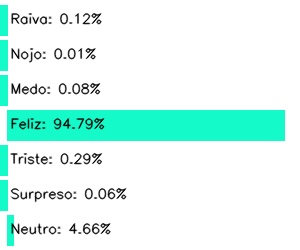

True

In [12]:
from tensorflow.keras.preprocessing.image import img_to_array

# Carrega o modelo
face_detection = cv2.CascadeClassifier(cascade_faces)
classificador_emocoes = load_model(caminho_modelo, compile=False)

expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"] # Define as emoções que o modelo pode reconhecer

original = imagem.copy()
faces = face_detection.detectMultiScale(original,scaleFactor=1.1,minNeighbors=3,minSize=(20,20))
cinza = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

if len(faces) > 0: # Verifica se alguma face foi detectada
    for (fX, fY, fW, fH) in faces:
      roi = cinza[fY:fY + fH, fX:fX + fW]
      roi = cv2.resize(roi, (48, 48))
      roi = roi.astype("float") / 255.0
      roi = img_to_array(roi)
      roi = np.expand_dims(roi, axis=0)
      preds = classificador_emocoes.predict(roi)[0]
      print(preds)
      emotion_probability = np.max(preds)
      label = expressoes[preds.argmax()]
      cv2.putText(original, label, (fX, fY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 255), 2, cv2.LINE_AA)
      cv2.rectangle(original, (fX, fY), (fX + fW, fY + fH),(0, 0, 255), 2)
else: # Informa caso nenhuma face seja encontrada
    print('Nenhuma face detectada')


cv2_imshow(original)

probabilidades = np.ones((250, 300, 3), dtype="uint8") * 255
# Mostra gráfico apenas se detectou uma face
if len(faces) == 1:
  for (i, (emotion, prob)) in enumerate(zip(expressoes, preds)):
      # Nome das emoções
      text = "{}: {:.2f}%".format(emotion, prob * 100)
      w = int(prob * 300)
      cv2.rectangle(probabilidades, (7, (i * 35) + 5),
      (w, (i * 35) + 35), (200, 250, 20), -1)
      cv2.putText(probabilidades, text, (10, (i * 35) + 23),
      cv2.FONT_HERSHEY_SIMPLEX, 0.45,
      (0, 0, 0), 1, cv2.LINE_AA)

  cv2_imshow(probabilidades) # Exibe o gráfico com as probabilidades das emoções

cv2.imwrite("captura.jpg",original) # Salva a imagem processada no arquivo captura.jpg
#cv2.destroyAllWindows()